# **Photonics Research Lab: Laser Systems and Application cluster task**

## Python Programming with Boris Algorithm (single electron, $E=0$, $B\neq 0$)

---

### **Instructions**

1. Debug the provided code.
2. Use it to simulate electron motion in a uniform magnetic field.
3. Present your findings in a concise, ***one-page PDF report.***

### **Objectives**

1. Be familiar with particle-in-cell (PIC) simulations
2. Implement and debug Python code (specifically the Boris algorithm)
3. Understand and explain cyclotron motion and compare predictions with simulations

### **Scoring (100 pts)**
1. Figure/visualization: 50%
2. Text/discussion: 20%
3. Code snippets & debugging: 30%

### **Output Requirements**
- Single A4 page PDF (surname_lsa_codingtask.PDF)
- Include:
    - Clear, labeled figures with captions
    - Short discussion of results
    - Relevant code snippets (highlight debugged lines)
- Suggested layout: figures top half, discussion & code bottom half

### **Due Date: 5:00 PM, 27 March 2026 (Friday)**

# **Debugging**

The program below contains some bugs that need removing. Fix those bugs and note them in your report.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import elementary_charge

plt.rcParams['figure.dpi'] = 100

m_elec = 9.1093837e-31  # electron mass [kg]
e_charge = elementary_charge
zi = 6
ze = 1

def dt_omega_crit(B):
    if np.linalg.norm(B) != 0:
        omega_c = np.abs(ze * e_charge) * np.linalg.norm(B) / m_elec
        return 0.01 / omega_c
    else:
        return 1e-14

def E(r):
    constant = 8.98755179e9
    eps = 1e-20  # to prevent singularity
    return constant * zi * e_charge * r / (np.linalg.norm(r)**3 + eps)

def update(r, v_half, B, dt, q, m):
    qp = q * dt / (2 * m)

    # half electric field acceleration
    v_minus = v_half + qp * E(r)

    # boris rotation
    t = qp * B
    s = 2 * t / (1 + np.dot(t, t))

    v_prime = v_minus + np.cross(v_minus, t)
    v_plus = v_minus + np.cross(v_prime, s)

    # second half electric field acceleration
    v_next = v_plus + qp * E(r)

    # position update
    r_next = r + v_next * dt

    return r_next, v_next

def classical_boris(r, v, B, Nt=5500):

    dt = dt_omega_crit(B)
    qe = -e_charge * ze

    # backward half-step initialization
    _, v = update(r, v, B, -0.5 * dt, qe, m_elec)

    R = np.zeros((Nt, 3))
    V = np.zeros((Nt, 3))

    R[0] = r
    V[0] = v

    for j in range(1, Nt):
        r, v = update(r, v, B, dt, qe, m_elec)
        R[j] = r
        V[j] = v

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    colors = np.linspace(0, 1, Nt)
    ax.scatter(R[:,0], R[:,1], R[:,2], c=colors, cmap='seismic', s=1)
    ax.scatter(R[0,0], R[0,1], R[0,2], color='blue', marker='x', label=fr'initial $e^-$ position')
    ax.scatter(R[-1,0], R[-1,1], R[-1,2], color='red', marker='*', label=fr'final $e^-$ position')
    ax.scatter(0,0,0, color='k', marker='o', label='ion')

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')

    ax.set_title(f'B = {B}', fontsize=10)
    ax.legend()

    return ax

# **Check the code!**

To see if you've gotten the debugging right, run the code using the parameters:

`r = np.array([1e-6, 0, 0])`

`v = np.array([0, 0, 0])`

`B = np.array([0, 0, 1.5])`

Here `r` represents the position vector , `v` the velocity vector, and `B` is the external magnetic field. The first, second, and third parameters for each line correspond to the $x-, y-, z-$components, respectively.

Using the corrected program and running with the above initial conditions, you should get the 3D plot below.

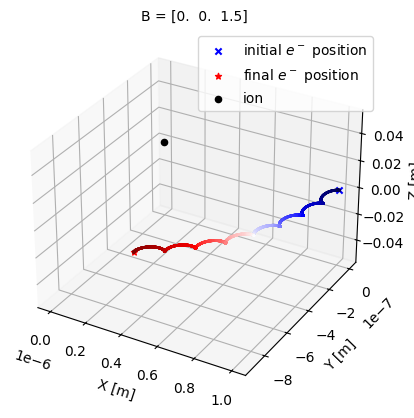

In [14]:
# Initial conditions
r = np.array([1e-6, 0, 0])
v = np.array([0, 0, 0])
B = np.array([0, 0, 1.5])

classical_boris(r, v, B, Nt=5000)
plt.show()

# **Questions**

Answer the following questions and put your answers in the report.
1. What is the analytical speed needed for an electron to move in a uniform circular motion for an electron orbiting a carbon ion? Can you show this with the code?

2. Pick a set of initial conditions (other than a simple circular orbit) and explain the motion using the Lorentz force. How does the velocity of the electron affect the gyrodynamics?

3. How does changing $B$ affect the dynamics (Larmor radius, frequency)?

4. Briefly comment on the role of timestep $dt$. What would happen if you use large numbers like $dt=10$?

5. (Optional): Play with the conditions and check what patterns you can get by adjusting $r, v, B$ and `Nt`! :)